# Import Libraries

In [493]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Data Collection and Processing

In [494]:
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [495]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [496]:
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns=breast_cancer_dataset.feature_names)

In [497]:
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [498]:
data_frame['label'] = breast_cancer_dataset.target

In [499]:
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [500]:
data_frame.shape

(569, 31)

In [501]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [502]:
data_frame.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

In [503]:
data_frame['label'].value_counts()

label
1    357
0    212
Name: count, dtype: int64

In [504]:
data_frame.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


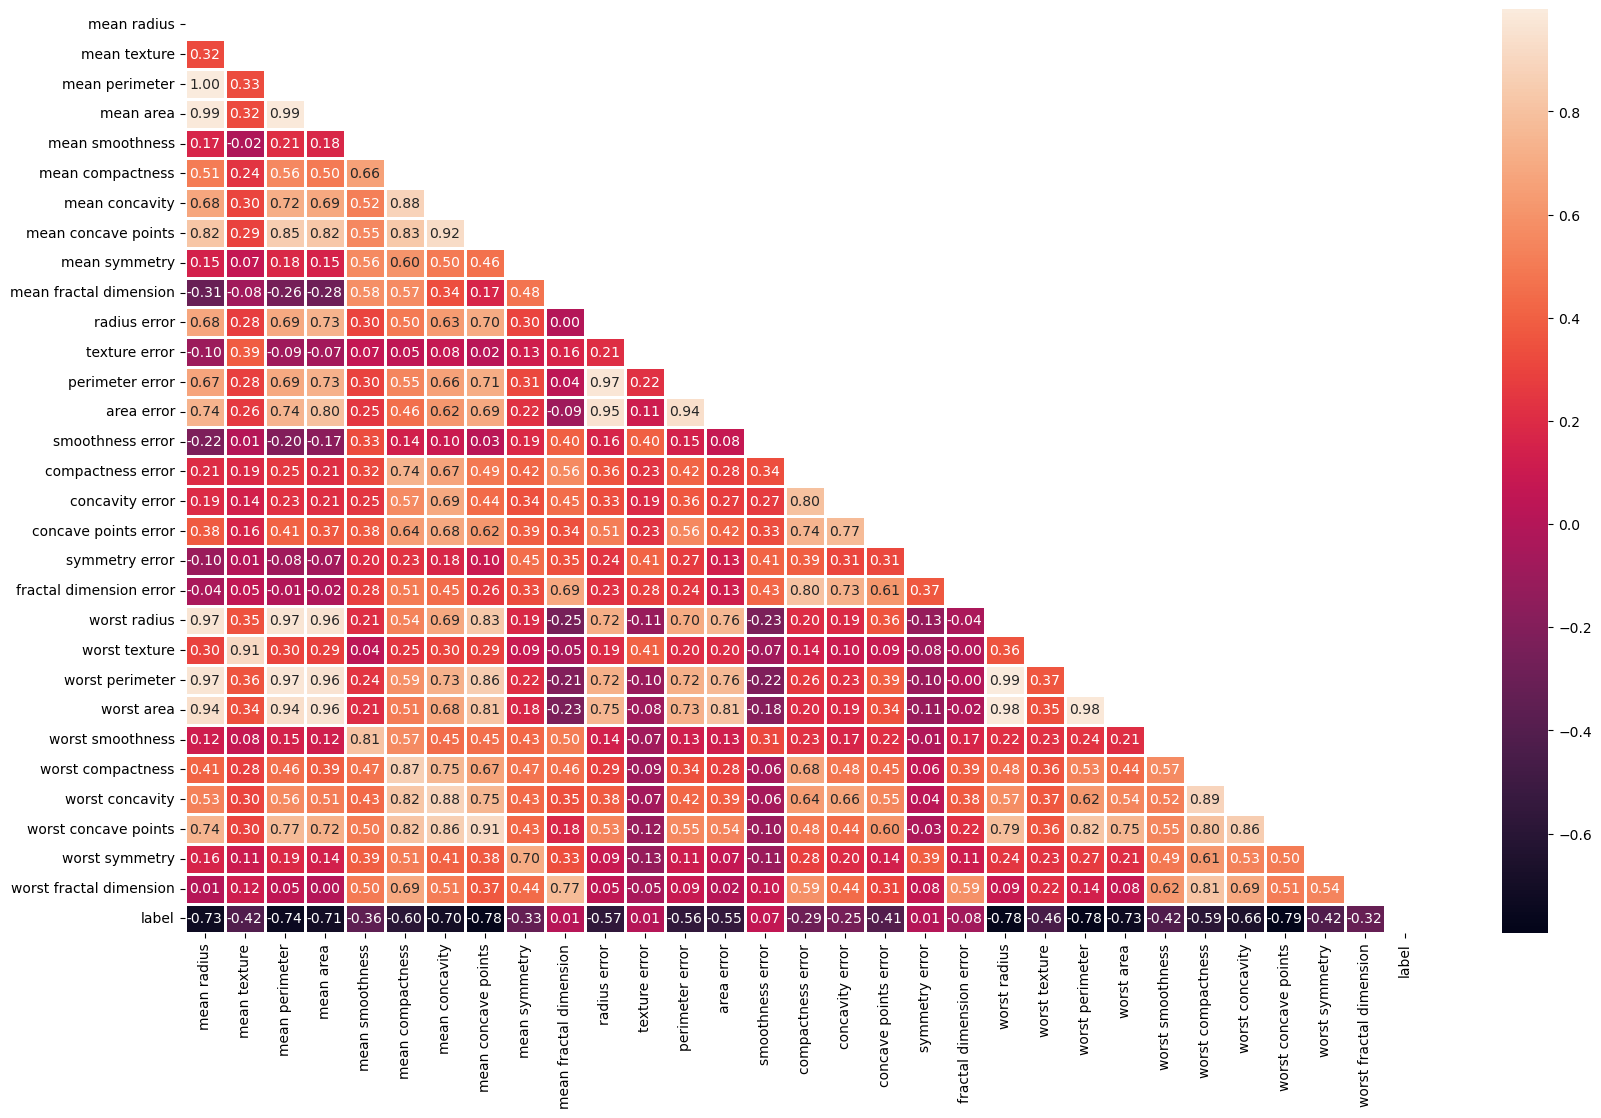

In [505]:
plt.figure(figsize=(20,12))
corr=data_frame.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt = ".2f")
plt.show()

In [506]:
# feature selection
corr_matrix = data_frame.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

to_drop = [x for x in tri_df.columns if any(tri_df[x]>0.92)]

data_frame = data_frame.drop(to_drop, axis=1)

print(data_frame.shape[1])

23


In [507]:
data_frame.head()

,mean texture,mean smoothness,mean compactness,mean concave points,mean symmetry,mean fractal dimension,texture error,area error,smoothness error,compactness error,...,fractal dimension error,worst texture,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,153.40,0.006399,0.04904,...,0.006193,17.33,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,74.08,0.005225,0.01308,...,0.003532,23.41,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,94.03,0.006150,0.04006,...,0.004571,25.53,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,27.23,0.009110,0.07458,...,0.009208,26.50,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,94.44,0.011490,0.02461,...,0.005115,16.67,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Separating the features and target

In [508]:
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

In [509]:
X

,mean texture,mean smoothness,mean compactness,mean concave points,mean symmetry,mean fractal dimension,texture error,area error,smoothness error,compactness error,...,symmetry error,fractal dimension error,worst texture,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,153.40,0.006399,0.04904,...,0.03003,0.006193,17.33,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,74.08,0.005225,0.01308,...,0.01389,0.003532,23.41,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,94.03,0.006150,0.04006,...,0.02250,0.004571,25.53,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,27.23,0.009110,0.07458,...,0.05963,0.009208,26.50,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,94.44,0.011490,0.02461,...,0.01756,0.005115,16.67,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,22.39,0.11100,0.11590,0.13890,0.1726,0.05623,1.2560,158.70,0.010300,0.02891,...,0.01114,0.004239,26.40,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,28.25,0.09780,0.10340,0.09791,0.1752,0.05533,2.4630,99.04,0.005769,0.02423,...,0.01898,0.002498,38.25,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,28.08,0.08455,0.10230,0.05302,0.1590,0.05648,1.0750,48.55,0.005903,0.03731,...,0.01318,0.003892,34.12,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,29.33,0.11780,0.27700,0.15200,0.2397,0.07016,1.5950,86.22,0.006522,0.06158,...,0.02324,0.006185,39.42,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [510]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: label, Length: 569, dtype: int32

In [511]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [512]:
print(X.shape, X_train.shape, X_test.shape)

(569, 22) (455, 22) (114, 22)


In [513]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

print("Before Oversampling:\n", Y_train.value_counts())
print("After Oversampling:\n", Y_train_resampled.value_counts())

Before Oversampling:
 label
1    286
0    169
Name: count, dtype: int64
After Oversampling:
 label
1    286
0    286
Name: count, dtype: int64


In [514]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Model Training (Logistic)

In [515]:
logisticModel = LogisticRegression(max_iter=10000)

In [516]:
logisticModel.fit(X_train_scaled, Y_train_resampled)

LogisticRegression(max_iter=10000)

# Model Evaluation (Logistic)

In [517]:
logistic_x_train = logisticModel.predict(X_train_scaled)

In [518]:
print("Classification Report Training (Logistic Regression):")
print(classification_report(Y_train_resampled, logistic_x_train))

Classification Report Training (Logistic Regression):
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       286
           1       0.94      0.98      0.96       286

    accuracy                           0.96       572
   macro avg       0.96      0.96      0.96       572
weighted avg       0.96      0.96      0.96       572



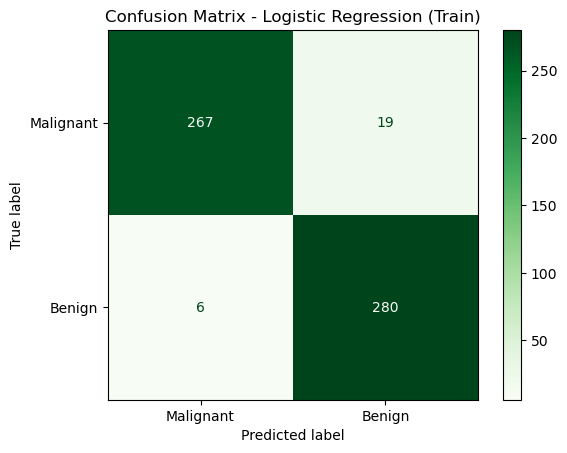

In [519]:
cm_log_train = confusion_matrix(Y_train_resampled, logistic_x_train)
disp_log_train = ConfusionMatrixDisplay(confusion_matrix=cm_log_train, display_labels=["Malignant", "Benign"])
disp_log_train.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Logistic Regression (Train)")
plt.show()

In [520]:
logistic_x_test = logisticModel.predict(X_test_scaled)

In [521]:
print("Classification Report (Logistic):")
print(classification_report(Y_test, logistic_x_test))

Classification Report (Logistic):
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



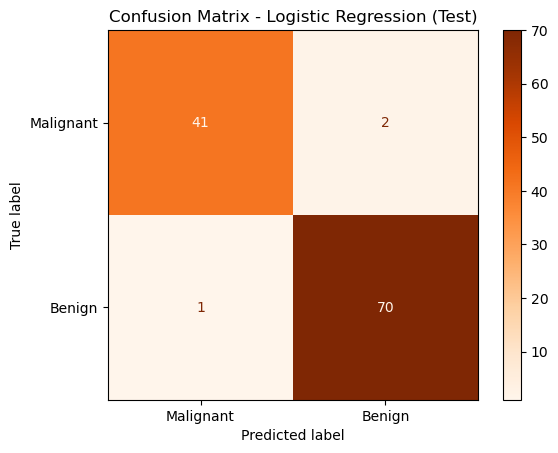

In [522]:
cm_log = confusion_matrix(Y_test, logistic_x_test)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Malignant", "Benign"])
disp_log.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Logistic Regression (Test)")
plt.show()

# Scaling data -> for SVM

In [523]:
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train_resampled)
# X_test_scaled = scaler.transform(X_test)

# Model Training (SVM)

In [524]:
svmModel = SVC(kernel='linear', probability=True)

In [525]:
svmModel.fit(X_train_scaled, Y_train_resampled)

SVC(kernel='linear', probability=True)

# Model Evaluation (SVM)

In [526]:
svm_x_train = svmModel.predict(X_train_scaled)

In [527]:
print("Classification Report Training (SVM):")
print(classification_report(Y_train_resampled, svm_x_train))

Classification Report Training (SVM):
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       286
           1       0.95      0.99      0.97       286

    accuracy                           0.97       572
   macro avg       0.97      0.97      0.97       572
weighted avg       0.97      0.97      0.97       572



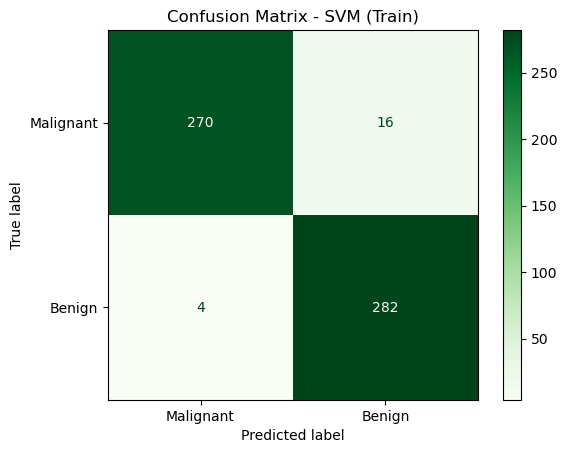

In [528]:
cm_svm_train = confusion_matrix(Y_train_resampled, svm_x_train)

disp_svm_train = ConfusionMatrixDisplay(confusion_matrix=cm_svm_train, display_labels=["Malignant", "Benign"])
disp_svm_train.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - SVM (Train)")
plt.show()

In [529]:
svm_x_test = svmModel.predict(X_test_scaled)

In [530]:
print("Classification Report (SVM):")
print(classification_report(Y_test, svm_x_test))

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



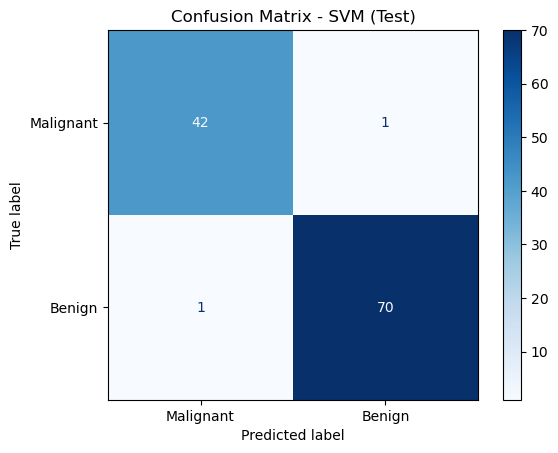

In [531]:
cm_svm = confusion_matrix(Y_test, svm_x_test)

disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Malignant", "Benign"])
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM (Test)")
plt.show()

# Cross Validation

In [532]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

svm_pipeline = make_pipeline(MinMaxScaler(), SVC(kernel='linear', probability=True))
svm_cv_scores = cross_val_score(svm_pipeline, X, Y, cv=5)
print("Akurasi tiap fold (SVM):", np.round(svm_cv_scores * 100, 2), "%")
print("Rata-rata akurasi SVM (5-Fold CV):", np.round(np.mean(svm_cv_scores) * 100, 2), "%")

logreg_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression(max_iter=10000))
logreg_cv_scores = cross_val_score(logreg_pipeline, X, Y, cv=5)
print("Akurasi tiap fold (Logistic Regression):", np.round(logreg_cv_scores * 100, 2), "%")
print("Rata-rata akurasi Logistic Regression (5-Fold CV):", round(np.mean(logreg_cv_scores) * 100, 2), "%")

Akurasi tiap fold (SVM): [95.61 97.37 95.61 95.61 97.35] %
Rata-rata akurasi SVM (5-Fold CV): 96.31 %
Akurasi tiap fold (Logistic Regression): [94.74 96.49 94.74 93.86 96.46] %
Rata-rata akurasi Logistic Regression (5-Fold CV): 95.26 %


# Hyperparameter Tuning

=== Hyperparameter Tuning SVM ===
Best Parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best Cross-Validation Accuracy: 97.89 %

Classification Report (Best Tuned SVM):
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



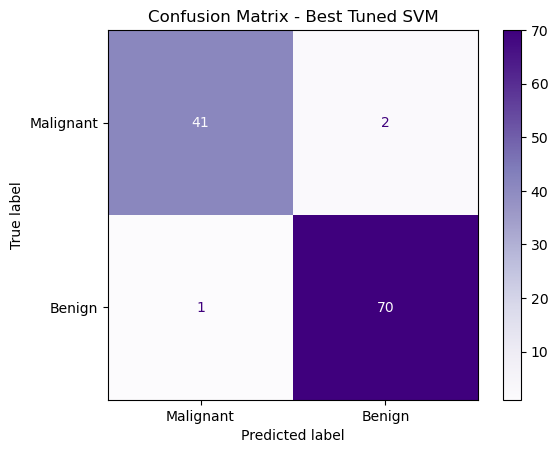

In [533]:
param_grid = {
    'svc__C': [0.01, 0.05, 0.5, 0.1, 1, 10, 15, 20, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

grid = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X, Y)

print("=== Hyperparameter Tuning SVM ===")
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", round(grid.best_score_ * 100, 2), "%")

best_svm_model = grid.best_estimator_
best_svm_model.fit(X_train_resampled, Y_train_resampled)
best_svm_pred = best_svm_model.predict(X_test)

print("\nClassification Report (Best Tuned SVM):")
print(classification_report(Y_test, best_svm_pred))

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test, best_svm_pred),
                        display_labels=["Malignant", "Benign"]).plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix - Best Tuned SVM")
plt.show()

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



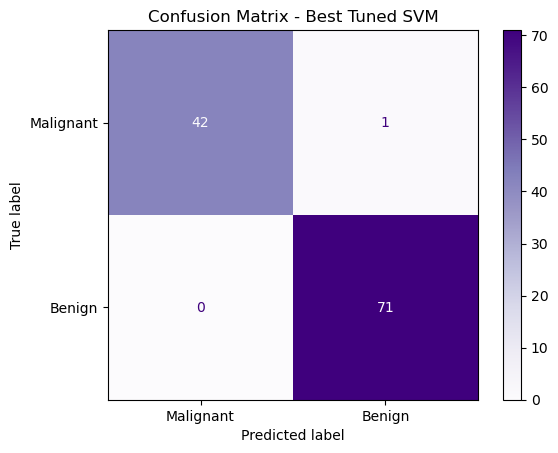

In [534]:
     from imblearn.pipeline import Pipeline as ImbPipeline
     from imblearn.over_sampling import SMOTE

     # Pipeline dengan SMOTE
     svm_pipeline_tuned = ImbPipeline([
         ('smote', SMOTE(random_state=42)),
         ('scaler', MinMaxScaler()),
         ('svc', SVC(probability=True))
     ])

     param_grid = {
         'svc__C': [0.1, 1, 10, 100],  # Kurangi grid, fokus linear dulu
         'svc__kernel': ['linear'],     # Mulai dengan linear saja, tambah rbf jika perlu
         'svc__gamma': ['scale']        # Hanya jika pakai rbf
     }

     grid = GridSearchCV(svm_pipeline_tuned, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
     grid.fit(X, Y)  # Sekarang CV include SMOTE per fold!

     # Evaluasi
     best_svm_model = grid.best_estimator_
     best_svm_pred = best_svm_model.predict(X_test)  # Langsung predict, karena pipeline handle semuanya
     print(classification_report(Y_test, best_svm_pred))
     
     ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test, best_svm_pred),
                        display_labels=["Malignant", "Benign"]).plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix - Best Tuned SVM")
plt.show()

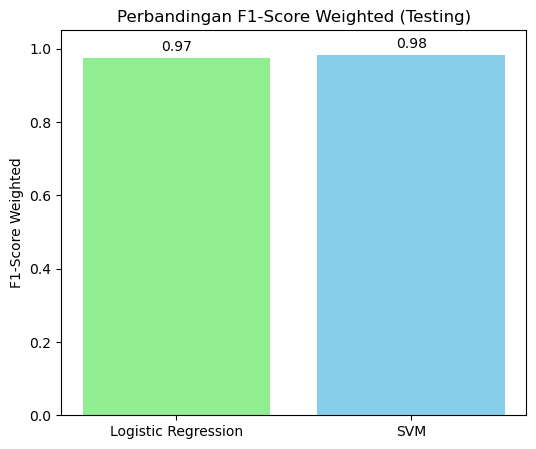

In [535]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# === Logistic Regression (Test) ===
log_test_pred = logisticModel.predict(X_test_scaled)
log_test_report = classification_report(Y_test, log_test_pred, output_dict=True)
log_test_f1 = log_test_report["weighted avg"]["f1-score"]

# === SVM (Test) ===
svm_test_pred = svmModel.predict(X_test_scaled)
svm_test_report = classification_report(Y_test, svm_test_pred, output_dict=True)
svm_test_f1 = svm_test_report["weighted avg"]["f1-score"]

# === Plot perbandingan F1-score Weighted (Test) ===
models = ["Logistic Regression", "SVM"]
f1_scores = [log_test_f1, svm_test_f1]

plt.figure(figsize=(6,5))
bars = plt.bar(models, f1_scores, color=["lightgreen", "skyblue"])
plt.title("Perbandingan F1-Score Weighted (Testing)")
plt.ylabel("F1-Score Weighted")
plt.ylim(0, 1.05)

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0,3),
                 textcoords="offset points",
                 ha="center", va="bottom")

plt.show()
